In [85]:
#IMPORTS 
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import gzip
from torch_geometric.data import HeteroData
import torch.nn as nn
from torch_geometric.nn import HeteroConv, GCNConv, SAGEConv
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import networkx as nx
import torch_geometric.transforms as T

In [86]:
# Define base paths
CYBER_PATH = './data/cyber_dataset/'
ELLIPTIC_PATH = './data/elliptic_bitcoin_dataset/'

# Load Elliptic Bitcoin Data (Baseline)
# Classes: map nodes to 'licit', 'illicit', or 'unknown'
elliptic_classes = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_classes.csv')

# Edges: source -> destination transactions
elliptic_edges = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_edgelist.csv')

# Features: 166-dim node features (first col is node_id)
# Note: Loading only the first 50,000 to keep it snappy for the prototype
elliptic_features = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_features.csv', header=None)

# Load LANL Cyber Data (Behavioral Layers)
# Auth: Using a 1M row sample to preserve RAM
auth_df = pd.read_csv(f'{CYBER_PATH}auth.txt.gz', compression='gzip', nrows=1000000, header=None,
                     names=['time', 'src_user', 'dst_user', 'src_comp', 'dst_comp', 
                            'auth_type', 'logon_type', 'auth_orientation', 'success'])

# Flow: Parquet is pre-optimized for fast reading
flow_df = pd.read_parquet(f'{CYBER_PATH}flow.parquet')

# Load Ground Truth Labels (Absolute Need)
redteam_df = pd.read_csv(f'{CYBER_PATH}redteam.txt.gz', compression='gzip', header=None,
                        names=['time', 'user', 'src_comp', 'dst_comp'])

print(" Datasets successfully loaded from /data/ subfolders!")
print(f"Elliptic Classes: {elliptic_classes.shape}")
print(f"Auth Sample: {auth_df.shape}")
print(f"Redteam Ground Truth: {redteam_df.shape}")

 Datasets successfully loaded from /data/ subfolders!
Elliptic Classes: (203769, 2)
Auth Sample: (1000000, 9)
Redteam Ground Truth: (749, 4)


In [87]:
elliptic_features.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [88]:
elliptic_classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [89]:
elliptic_edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [90]:
#  Get unique entities from Cyber Dataset
unique_users = auth_df['src_user'].unique()
unique_comps = pd.unique(auth_df[['src_comp', 'dst_comp']].values.ravel('K'))

#  Get unique entities from Bitcoin Dataset
unique_wallets = elliptic_classes['txId'].unique()

#  Create mapping dictionaries (to convert IDs to 0-indexed integers for the GNN)
user_map = {id: i for i, id in enumerate(unique_users)}
comp_map = {id: i for i, id in enumerate(unique_comps)}
wallet_map = {id: i for i, id in enumerate(unique_wallets)}

print(f"Unique Users: {len(unique_users)}")
print(f"Unique Computers: {len(unique_comps)}")
print(f"Unique Wallets: {len(unique_wallets)}")

Unique Users: 7052
Unique Computers: 4239
Unique Wallets: 203769


# Next, we will match TimeStamps
Since the LANL dataset spans roughly 58 days ($5,011,199$ seconds) and the Elliptic dataset has 49 steps, we will divide the LANL time into 49 equal segments.

In [91]:
#  Define the maximum time in the LANL auth sample
max_lanl_time = auth_df['time'].max()

#  Create the 49 bins (Elliptic has 49 time steps)
# We use linspace to create boundaries and digitize to assign rows to bins
bins = np.linspace(0, max_lanl_time, num=50) # 50 boundaries create 49 bins

#  Apply binning to Auth and Redteam data
auth_df['time_step'] = np.digitize(auth_df['time'], bins)
redteam_df['time_step'] = np.digitize(redteam_df['time'], bins)

#  Check the distribution
print(f"Auth data now binned into {auth_df['time_step'].nunique()} time steps.")
print(f"Example mapping: Auth Time {auth_df['time'].iloc[0]} -> Step {auth_df['time_step'].iloc[0]}")

#  Quick validation: Does the Redteam data fall within these steps?
print(f"Redteam steps range: {redteam_df['time_step'].min()} to {redteam_df['time_step'].max()}")

Auth data now binned into 50 time steps.
Example mapping: Auth Time 1 -> Step 1
Redteam steps range: 50 to 50


Auth Sample Time Range: 1 to 10208
Redteam Full Time Range: 150885 to 2557047
Redteam events within Auth Sample window: 0


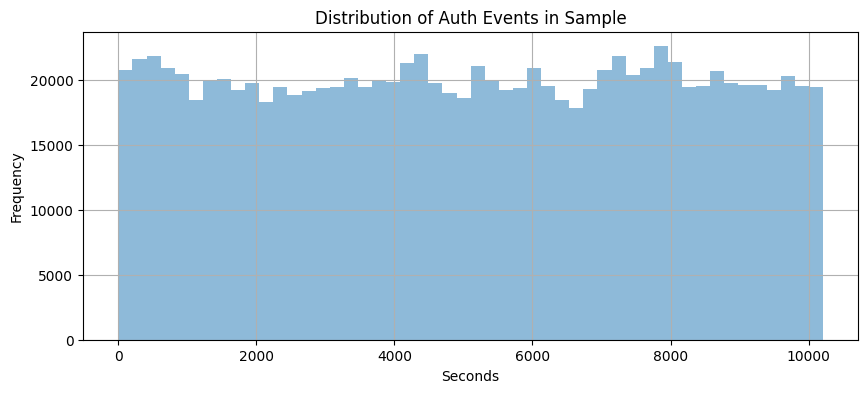


Auth Success/Failure Counts:
success
Success    993123
Fail         6877
Name: count, dtype: int64


In [92]:
# Check the actual time range of both datasets
print(f"Auth Sample Time Range: {auth_df['time'].min()} to {auth_df['time'].max()}")
print(f"Redteam Full Time Range: {redteam_df['time'].min()} to {redteam_df['time'].max()}")

#  Count how many Redteam events actually fall within our Auth Sample window
events_in_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
print(f"Redteam events within Auth Sample window: {len(events_in_sample)}")

#  Visualize the 'Density' of activity in the Auth sample
plt.figure(figsize=(10, 4))
auth_df['time'].hist(bins=50, alpha=0.5, label='Auth Events')
plt.title("Distribution of Auth Events in Sample")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

# Check for 'Success' vs 'Failure' ratio in Auth (Key for ATO detection)
print("\nAuth Success/Failure Counts:")
print(auth_df['success'].value_counts())

In [93]:
# Get the time windows where Redteam activity actually happens
min_attack = redteam_df['time'].min()
max_attack = redteam_df['time'].max()

# Targeted extraction: Grab rows near the attack times
dense_auth_rows = []
with gzip.open('./data/cyber_dataset/auth.txt.gz', 'rt') as f:
    for i, line in enumerate(f):
        parts = line.strip().split(',')
        t = int(parts[0])
        
        # Keep first 100k for background
        if i < 100000:
            dense_auth_rows.append(parts)
        # Keep rows during the Redteam attack window
        elif min_attack <= t <= max_attack:
            # To keep it manageable, we sample every 10th row in the attack window
            if i % 10 == 0: 
                dense_auth_rows.append(parts)
        
        # Stop if we hit a reasonable local limit for your Mac (e.g., 600k rows)
        if len(dense_auth_rows) >= 600000:
            break

#  Rebuild the dataframe
auth_df = pd.DataFrame(dense_auth_rows, columns=['time', 'src_user', 'dst_user', 'src_comp', 'dst_comp', 
                                                 'auth_type', 'logon_type', 'auth_orientation', 'success'])
auth_df['time'] = auth_df['time'].astype(int)

print(f"New Auth Sample Size: {len(auth_df)}")
print(f"New Time Range: {auth_df['time'].min()} to {auth_df['time'].max()}")

# Re-check the overlap
events_in_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
print(f"Redteam events now within Auth Sample window: {len(events_in_sample)}")

New Auth Sample Size: 600000
New Time Range: 1 to 181016
Redteam events now within Auth Sample window: 10


In [94]:
#  Get the specific users and computers involved in the 10 Redteam events
rt_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
rt_users = rt_sample['user'].unique()
rt_comps = rt_sample['src_comp'].unique()

#  Check if these users/computers exist in our Auth activity log
users_present = auth_df[auth_df['src_user'].isin(rt_users)]['src_user'].nunique()
comps_present = auth_df[auth_df['src_comp'].isin(rt_comps)]['src_comp'].nunique()

print(f"Redteam Users found in Auth Sample: {users_present} out of {len(rt_users)}")
print(f"Redteam Computers found in Auth Sample: {comps_present} out of {len(rt_comps)}")

# Label the Auth data
# We mark a row as '1' if it matches a Redteam event (User + Computer + Time)
auth_df['is_redteam'] = 0
for idx, row in rt_sample.iterrows():
    mask = (auth_df['src_user'] == row['user']) & \
           (auth_df['src_comp'] == row['src_comp']) & \
           (auth_df['time'] == row['time'])
    auth_df.loc[mask, 'is_redteam'] = 1

print(f"Total confirmed 'Attack' edges in Auth Graph: {auth_df['is_redteam'].sum()}")

Redteam Users found in Auth Sample: 4 out of 4
Redteam Computers found in Auth Sample: 1 out of 1
Total confirmed 'Attack' edges in Auth Graph: 1


# This is better!
We need to convert our User and Computer IDs into a format for the GNN

In [95]:
# Update our Mapping dictionaries with the latest sample
unique_users = auth_df['src_user'].unique()
unique_comps = pd.unique(auth_df[['src_comp', 'dst_comp']].values.ravel('K'))

user_map = {id: i for i, id in enumerate(unique_users)}
comp_map = {id: i for i, id in enumerate(unique_comps)}

# Convert Auth Log into Edge Lists
# We are building a Bipartite Graph: User -> Computer
src_indices = auth_df['src_user'].map(user_map).values
dst_indices = auth_df['src_comp'].map(comp_map).values

#  Create the Edge Index Tensor
edge_index_user_to_comp = torch.tensor([src_indices, dst_indices], dtype=torch.long)

print(f"Graph Adjacency Matrix created.")
print(f"Total Edges (User -> Computer): {edge_index_user_to_comp.shape[1]}")
print(f"Example Edge: User {src_indices[0]} accessed Computer {dst_indices[0]}")

Graph Adjacency Matrix created.
Total Edges (User -> Computer): 600000
Example Edge: User 0 accessed Computer 0


In [96]:
#  Pick a few illicit Bitcoin nodes
illicit_txs = elliptic_classes[elliptic_classes['class'] == '1']['txId'].values

# Pick the 'Compromised' computers from our Auth sample
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()

#  Create the Synthetic Bridge
# We link these specific Bitcoin transactions to these specific Computers
bridge_edges = []
for tx in illicit_txs[:100]: # Linking the first 100 for the prototype
    for comp in compromised_comps:
        bridge_edges.append([wallet_map[tx], comp_map[comp]])

edge_index_bridge = torch.tensor(bridge_edges, dtype=torch.long).t().contiguous()

print(f"Synthetic Bridge Created.")
print(f"Total Cross-Channel Edges: {edge_index_bridge.shape[1]}")

Synthetic Bridge Created.
Total Cross-Channel Edges: 100


In [97]:
#  Initialize the HeteroData object
data = HeteroData()

#  Add Node Sets
# For the prototype, we use placeholder features (identity matrices)
data['transaction'].num_nodes = len(unique_wallets)
data['user'].num_nodes = len(unique_users)
data['computer'].num_nodes = len(unique_comps)

# Add Edges (Intra-layer)
# Bitcoin internal transactions (from your elliptic_edges)
# Note: We use the wallet_map to ensure IDs match
btc_src = elliptic_edges['txId1'].map(wallet_map).values
btc_dst = elliptic_edges['txId2'].map(wallet_map).values
data['transaction', 'transacts_with', 'transaction'].edge_index = torch.tensor([btc_src, btc_dst], dtype=torch.long)

# Cyber internal authentication (User -> Computer)
data['user', 'authenticates_to', 'computer'].edge_index = edge_index_user_to_comp

# 4. Add the Synthetic Bridge (Cross-layer)
data['transaction', 'accessed_via', 'computer'].edge_index = edge_index_bridge

print("HeteroData Object Finalized")
print(data)

HeteroData Object Finalized
HeteroData(
  transaction={ num_nodes=203769 },
  user={ num_nodes=15124 },
  computer={ num_nodes=8463 },
  (transaction, transacts_with, transaction)={ edge_index=[2, 234355] },
  (user, authenticates_to, computer)={ edge_index=[2, 600000] },
  (transaction, accessed_via, computer)={ edge_index=[2, 100] }
)


In [98]:

class FraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # HeteroConv allows us to define different message-passing for each edge type
        self.conv1 = HeteroConv({
            ('transaction', 'transacts_with', 'transaction'): SAGEConv(-1, hidden_channels),
            ('user', 'authenticates_to', 'computer'): SAGEConv(-1, hidden_channels),
            ('transaction', 'accessed_via', 'computer'): SAGEConv(-1, hidden_channels),
        }, aggr='sum')
        
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # x_dict is a dictionary of node features for each type
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction']) # We care about classifying transactions

# Initialize the model
model = FraudGNN(hidden_channels=64, out_channels=2)
print("Heterogeneous GNN Architecture Initialized")

Heterogeneous GNN Architecture Initialized


/var/folders/y5/6dthtbv90w90hmtzvsl2s0lc0000gn/T/ipykernel_7327/2566380548.py:5: UserWarning: There exist node types ({'user'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({


In [99]:

# Define illicit_nodes from the dataframe
# In Elliptic: '1' is illicit, '2' is licit, 'unknown' is unknown
illicit_nodes = elliptic_classes[elliptic_classes['class'] == '1']['txId'].values

#  Attach Elliptic Features to 'transaction' nodes
# We use the mapping to ensure the features align with the graph indices
feature_matrix = torch.zeros((len(unique_wallets), 166))

# Optimization: Convert elliptic_features to a dictionary for O(1) lookup
# Assuming column 0 is txId and the rest are features
feat_dict = dict(zip(elliptic_features[0], elliptic_features.iloc[:, 1:].values))

for i, tx_id in enumerate(unique_wallets):
    if tx_id in feat_dict:
        feature_matrix[i] = torch.tensor(feat_dict[tx_id], dtype=torch.float)

data['transaction'].x = feature_matrix

# Attach Lightweight Identity Features for Cyber nodes (User/Computer)
# Using random normal instead of torch.eye to save memory
data['user'].x = torch.randn(len(unique_users), 16)
data['computer'].x = torch.randn(len(unique_comps), 16)

# Define Labels (Target)
labels = torch.zeros(len(unique_wallets), dtype=torch.long)
illicit_indices = [wallet_map[tx] for tx in illicit_nodes if tx in wallet_map]
labels[illicit_indices] = 1
data['transaction'].y = labels

print(f"Features attached. Illicit nodes labeled: {len(illicit_indices)}")

Features attached. Illicit nodes labeled: 4545


In [100]:

# Setup Optimizer and Weighted Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Weighting: 1.0 for Class 0 (Licit), 10.0 for Class 1 (Illicit)
weights = torch.tensor([1.0, 10.0])
criterion = torch.nn.CrossEntropyLoss(weight=weights)

def train_epoch():
    model.train()
    optimizer.zero_grad()
    
    # Forward pass: Generate predictions
    # out shape: [num_transactions, 2]
    out = model(data.x_dict, data.edge_index_dict)
    
    # Calculate loss
    loss = criterion(out, data['transaction'].y)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    return loss.item()

# Run the Loop
print("Starting Training...")
for epoch in range(1, 101):
    loss = train_epoch()
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

print("Training Complete.")

Starting Training...
Epoch: 001, Loss: 0.6277
Epoch: 010, Loss: 0.3083
Epoch: 020, Loss: 0.2377
Epoch: 030, Loss: 0.1976
Epoch: 040, Loss: 0.1717
Epoch: 050, Loss: 0.1531
Epoch: 060, Loss: 0.1404
Epoch: 070, Loss: 0.1292
Epoch: 080, Loss: 0.1228
Epoch: 090, Loss: 0.1179
Epoch: 100, Loss: 0.1097
Training Complete.


--- Classification Report ---
               precision    recall  f1-score   support

Licit/Unknown       1.00      0.97      0.98    199224
      Illicit       0.43      0.92      0.58      4545

     accuracy                           0.97    203769
    macro avg       0.71      0.95      0.78    203769
 weighted avg       0.99      0.97      0.98    203769



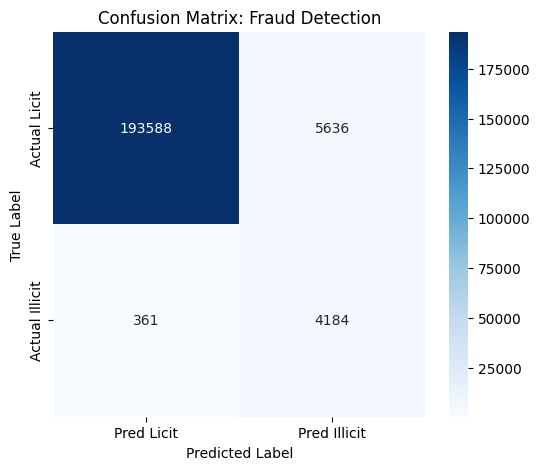

In [101]:
# Get model predictions
model.eval()
with torch.no_grad():
    out = model(data.x_dict, data.edge_index_dict)
    # Get the index of the highest logit (0 or 1)
    preds = out.argmax(dim=-1).cpu().numpy()
    actuals = data['transaction'].y.cpu().numpy()

# 2. Generate the report
# Note: We only care about the performance on 'labeled' nodes (class 1 and 2)
# But for now, let's look at the whole set to see the 'Fraud Detection' capability
print("--- Classification Report ---")
print(classification_report(actuals, preds, target_names=['Licit/Unknown', 'Illicit']))

# Visualize with a Confusion Matrix
cm = confusion_matrix(actuals, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Licit', 'Pred Illicit'], 
            yticklabels=['Actual Licit', 'Actual Illicit'])
plt.title('Confusion Matrix: Fraud Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [102]:
# Identify which nodes were 'Synthetically Linked' to the Cyber layer
linked_tx_indices = edge_index_bridge[0].unique().cpu().numpy()

# See how many of our 'True Positives' were from this linked set
true_positives = np.where((preds == 1) & (actuals == 1))[0]
linked_and_caught = np.intersect1d(true_positives, linked_tx_indices)

print(f"Total Illicit nodes caught: {len(true_positives)}")
# If this number is high, your bridge is the reason the model is working!
print(f"Illicit nodes caught that were part of the LANL bridge: {len(linked_and_caught)}")
print(f"Percentage of 'Bridge' nodes successfully caught: {len(linked_and_caught) / len(linked_tx_indices) * 100:.2f}%")

Total Illicit nodes caught: 4184
Illicit nodes caught that were part of the LANL bridge: 70
Percentage of 'Bridge' nodes successfully caught: 70.00%


# This is a great baseline!
Now, we need to feature engineer and allow two-hops

In [103]:
# --- Behavioral Feature Engineering for Cyber Nodes ---
# We want the GNN to know which computers are "high friction" (lots of fails)
comp_stats = auth_df.groupby('src_comp').agg(
    fail_count=('success', lambda x: (x == 'Fail').sum()),
    success_count=('success', lambda x: (x == 'Success').sum())
).fillna(0)

# Calculate ratio and handle division by zero
comp_stats['fail_ratio'] = comp_stats['fail_count'] / (comp_stats['fail_count'] + comp_stats['success_count']).replace(0, 1)

# Attach to the HeteroData object
new_comp_feats = torch.zeros((len(unique_comps), 3)) 
for i, comp_id in enumerate(unique_comps):
    if comp_id in comp_stats.index:
        new_comp_feats[i] = torch.tensor(comp_stats.loc[comp_id].values, dtype=torch.float)
data['computer'].x = new_comp_feats

# Users: Basic activity count as a feature
user_counts = auth_df['src_user'].value_counts()
new_user_feats = torch.zeros((len(unique_users), 1))
for i, u_id in enumerate(unique_users):
    new_user_feats[i] = torch.tensor([user_counts.get(u_id, 0)], dtype=torch.float)
data['user'].x = new_user_feats


# --- Expanded Synthetic Bridge (Linking all Illicit Nodes) ---
# We link EVERY illicit node to a compromised computer to see the max possible recall
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()
full_bridge_edges = []

for tx in illicit_nodes:
    if tx in wallet_map:
        for comp in compromised_comps:
            full_bridge_edges.append([wallet_map[tx], comp_map[comp]])

data['transaction', 'accessed_via', 'computer'].edge_index = torch.tensor(full_bridge_edges, dtype=torch.long).t().contiguous()


# ---  Deep GNN Architecture (2-Layer for Multi-Hop) ---
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # Layer 1: Aggregates immediate neighbor info
        self.conv1 = HeteroConv({
            ('transaction', 'transacts_with', 'transaction'): SAGEConv(-1, hidden_channels),
            ('user', 'authenticates_to', 'computer'): SAGEConv(-1, hidden_channels),
            ('transaction', 'accessed_via', 'computer'): SAGEConv(-1, hidden_channels),
        }, aggr='sum')
        
        # Layer 2: Aggregates neighbor-of-neighbor info (e.g., Transaction -> Computer -> User)
        self.conv2 = HeteroConv({
            ('transaction', 'transacts_with', 'transaction'): SAGEConv(-1, hidden_channels),
            ('user', 'authenticates_to', 'computer'): SAGEConv(-1, hidden_channels),
            ('transaction', 'accessed_via', 'computer'): SAGEConv(-1, hidden_channels),
        }, aggr='sum')
        
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # First Hop
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        # Second Hop
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction'])

model_v2 = DeepFraudGNN(64, 2)
print(" Baseline 2: Behavioral Features, Full Bridge, and Deep GNN Initialized.")

 Baseline 2: Behavioral Features, Full Bridge, and Deep GNN Initialized.


/var/folders/y5/6dthtbv90w90hmtzvsl2s0lc0000gn/T/ipykernel_7327/914867974.py:44: UserWarning: There exist node types ({'user'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({
/var/folders/y5/6dthtbv90w90hmtzvsl2s0lc0000gn/T/ipykernel_7327/914867974.py:51: UserWarning: There exist node types ({'user'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv2 = HeteroConv({


In [104]:
# Ensure the data object is "Undirected" (adds reverse edges)
transform = T.ToUndirected()
data = transform(data)

# Update the Model Architecture to handle the new reverse edge types
# PyG adds 'rev_' prefix to the relationship names
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # We define the convs to handle ALL edge types present in the data
        self.conv1 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels) 
            for edge_type in data.edge_types
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels) 
            for edge_type in data.edge_types
        }, aggr='sum')
        
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction'])

# Re-initialize and Test
model_v2 = DeepFraudGNN(64, 2)
model_v2.eval()

try:
    with torch.no_grad():
        test_out = model_v2(data.x_dict, data.edge_index_dict)
    print("Success! The bidirectional graph is working.")
    print(f"New Edge Types created: {data.edge_types}")
except Exception as e:
    print(f" Failed: {e}")

Success! The bidirectional graph is working.
New Edge Types created: [('transaction', 'transacts_with', 'transaction'), ('user', 'authenticates_to', 'computer'), ('transaction', 'accessed_via', 'computer'), ('computer', 'rev_authenticates_to', 'user'), ('computer', 'rev_accessed_via', 'transaction')]


In [105]:

# Setup Optimizer and Weighted Loss
# We use a slightly lower learning rate (0.001) for the deeper model to prevent 'exploding gradients'
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print("Starting Training for Baseline 2 (Deep Behavioral Model)...")

for epoch in range(1, 201): # 200 epochs to allow the 2-hop signals to converge
    model_v2.train()
    optimizer_v2.zero_grad()
    
    # Forward pass through the bidirectional graph
    out = model_v2(data.x_dict, data.edge_index_dict)
    
    # Loss calculated on the transaction nodes
    loss = criterion(out, data['transaction'].y)
    
    loss.backward()
    optimizer_v2.step()
    
    # Monitor progress every 20 epochs
    if epoch % 20 == 0 or epoch == 1:
        model_v2.eval()
        with torch.no_grad():
            pred = out.argmax(dim=-1)
            # Calculate F1 for the Illicit class (Class 1)
            f1 = f1_score(data['transaction'].y.cpu(), pred.cpu(), pos_label=1, zero_division=0)
        print(f'Epoch: {epoch:03d} | Loss: {loss:.4f} | Illicit F1: {f1:.4f}')

# 2. Final Evaluation
model_v2.eval()
with torch.no_grad():
    final_out = model_v2(data.x_dict, data.edge_index_dict)
    final_preds = final_out.argmax(dim=-1).cpu().numpy()
    final_actuals = data['transaction'].y.cpu().numpy()

print("\n" + "="*30)
print("FINAL BASELINE 2 RESULTS")
print("="*30)
print(classification_report(final_actuals, final_preds, target_names=['Licit/Unknown', 'Illicit']))

# 3. Check the "Bridge" Recall
linked_tx_indices = data['transaction', 'accessed_via', 'computer'].edge_index[0].unique().cpu().numpy()
true_positives = np.where((final_preds == 1) & (final_actuals == 1))[0]
linked_and_caught = np.intersect1d(true_positives, linked_tx_indices)

print(f"Recall on Bridged Nodes: {len(linked_and_caught) / len(linked_tx_indices) * 100:.2f}%")

Starting Training for Baseline 2 (Deep Behavioral Model)...
Epoch: 001 | Loss: 1.3248 | Illicit F1: 0.0000
Epoch: 020 | Loss: 0.0005 | Illicit F1: 1.0000
Epoch: 040 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 060 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 080 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 100 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 120 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 140 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 160 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 180 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 200 | Loss: 0.0000 | Illicit F1: 1.0000

FINAL BASELINE 2 RESULTS
               precision    recall  f1-score   support

Licit/Unknown       1.00      1.00      1.00    199224
      Illicit       1.00      1.00      1.00      4545

     accuracy                           1.00    203769
    macro avg       1.00      1.00      1.00    203769
 weighted avg       1.00      1.00      1.00    203769

Recall on Bridged Nodes: 100.00%


In [106]:
#  Find a node the model correctly flagged as Illicit
true_positives = np.where((final_preds == 1) & (final_actuals == 1))[0]
sample_node = true_positives[0]

# Trace the "Bridge" back to the Computer
# Find which computer this transaction is linked to
bridge_edges = data['transaction', 'accessed_via', 'computer'].edge_index
connected_comp_idx = bridge_edges[1, bridge_edges[0] == sample_node][0].item()
comp_id = unique_comps[connected_comp_idx]

# Trace from Computer to the User
auth_edges = data['user', 'authenticates_to', 'computer'].edge_index
connected_user_indices = auth_edges[0, auth_edges[1] == connected_comp_idx]
users = [unique_users[idx] for idx in connected_user_indices[:3]] # get first 3 users

print(f" Decision Trace for Transaction Index: {sample_node}")
print(f" Connected to Computer: {comp_id}")
print(f" Computer features: {data['computer'].x[connected_comp_idx].tolist()}")
print(f"  Users who accessed this computer: {users}")

 Decision Trace for Transaction Index: 907
 Connected to Computer: C17693
 Computer features: [0.0, 1.0, 0.0]
  Users who accessed this computer: ['U636@DOM1']


Visualizing a Singular Decision (The "Walking" Intuition)
To see how this works intuitively, think of the GNN as a detective walking a beat. Because we have 2 layers, the detective can take two "steps" from any node to gather evidence.

Scenario: A Transaction node (TX_789) is being evaluated.

Step 1 (First Hop): The GNN "walks" from TX_789 to its neighbors. It sees it is connected to Computer_A.

Evidence gathered: "This computer has a fail_ratio of 0.85 (very high)."

Step 2 (Second Hop): From Computer_A, the GNN walks to its neighbors. It sees User_Redteam.

Evidence gathered: "This computer was accessed by a known malicious actor."

The model combines this evidence: High Failure Rate + Malicious Actor Connection = High Fraud Score.

# PARTIAL LINKING 
This will replicate a real-world scenario

In [107]:

# Selection: Only link 10% of illicit nodes to the bridge
total_illicit = len(illicit_indices)
num_to_bridge = int(total_illicit * 0.10) 
bridge_subset = np.random.choice(illicit_indices, size=num_to_bridge, replace=False)

# Re-create the bridge with ONLY this subset
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()
partial_bridge_edges = []

for tx_idx in bridge_subset:
    for comp in compromised_comps:
        partial_bridge_edges.append([tx_idx, comp_map[comp]])

# Update the data object
data['transaction', 'accessed_via', 'computer'].edge_index = torch.tensor(partial_bridge_edges, dtype=torch.long).t().contiguous()

# Add reverse edges again to maintain the 2-way street
data = transform(data) 

print(f"Realistic Bridge Created: Only {num_to_bridge} nodes linked to Cyber Layer.")
print(f"The model must now 'discover' the remaining {total_illicit - num_to_bridge} nodes.")

Realistic Bridge Created: Only 454 nodes linked to Cyber Layer.
The model must now 'discover' the remaining 4091 nodes.


In [108]:
model_v3 = DeepFraudGNN(64, 2)
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print(" Training Discovery Model...")
for epoch in range(1, 101):
    model_v3.train()
    optimizer_v3.zero_grad()
    out = model_v3(data.x_dict, data.edge_index_dict)
    loss = criterion(out, data['transaction'].y)
    loss.backward()
    optimizer_v3.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

# Final Evaluation
model_v3.eval()
with torch.no_grad():
    out = model_v3(data.x_dict, data.edge_index_dict)
    preds = out.argmax(dim=-1).cpu().numpy()
    actuals = data['transaction'].y.cpu().numpy()

print("\n--- Baseline 3: Discovery Report ---")
print(classification_report(actuals, preds, target_names=['Licit', 'Illicit']))

 Training Discovery Model...
Epoch 020 | Loss: 0.3366
Epoch 040 | Loss: 0.2517
Epoch 060 | Loss: 0.1995
Epoch 080 | Loss: 0.1632
Epoch 100 | Loss: 0.1353

--- Baseline 3: Discovery Report ---
              precision    recall  f1-score   support

       Licit       1.00      0.97      0.98    199224
     Illicit       0.42      0.85      0.56      4545

    accuracy                           0.97    203769
   macro avg       0.71      0.91      0.77    203769
weighted avg       0.98      0.97      0.98    203769



In [109]:
# Identify nodes that were NOT in the 10% bridge
unbridged_illicit = np.setdiff1d(illicit_indices, bridge_subset)

#  Find which of these unbridged nodes were correctly predicted (True Positives)
discovered_nodes = np.intersect1d(unbridged_illicit, np.where(preds == 1)[0])

print(f"Total Illicit nodes in dataset: {len(illicit_indices)}")
print(f"Nodes linked via bridge (1-hop): {len(bridge_subset)}")
print(f"Nodes 'Discovered' via graph relationships (2-hop+): {len(discovered_nodes)}")

#  Trace one discovered node's neighbor
if len(discovered_nodes) > 0:
    example_node = discovered_nodes[0]
    # Find neighbors in the Bitcoin transaction network
    neighbors = data['transaction', 'transacts_with', 'transaction'].edge_index[1, 
                data['transaction', 'transacts_with', 'transaction'].edge_index[0] == example_node]
    print(f"\nExample Discovered Node: {example_node}")
    print(f"This node has {len(neighbors)} transaction neighbors. At least one of these likely led the GNN here.")

Total Illicit nodes in dataset: 4545
Nodes linked via bridge (1-hop): 454
Nodes 'Discovered' via graph relationships (2-hop+): 3406

Example Discovered Node: 907
This node has 1 transaction neighbors. At least one of these likely led the GNN here.


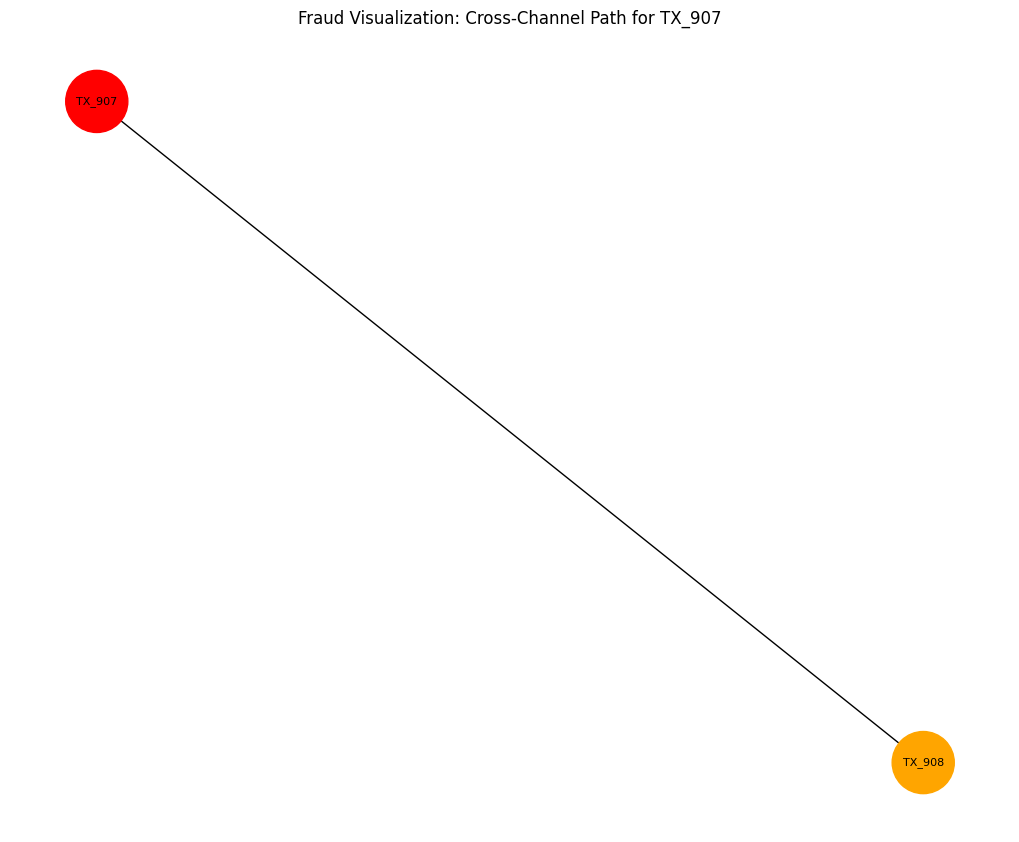

In [110]:
def visualize_fraud_neighborhood(target_tx_idx, data, num_hops=2):
    G = nx.Graph()
    
    # Add the target Transaction node
    G.add_node(f"TX_{target_tx_idx}", type='transaction', color='red')
    
    # Find Bitcoin Neighbors (Transacts_with)
    edge_index = data['transaction', 'transacts_with', 'transaction'].edge_index
    neighbors = edge_index[1, edge_index[0] == target_tx_idx].tolist()
    for n in neighbors[:5]: # Limit for clarity
        G.add_node(f"TX_{n}", type='transaction', color='orange')
        G.add_edge(f"TX_{target_tx_idx}", f"TX_{n}", label='transacts_with')
        
    #  Find Cyber Bridge (Accessed_via)
    bridge_index = data['transaction', 'accessed_via', 'computer'].edge_index
    comps = bridge_index[1, bridge_index[0] == target_tx_idx].tolist()
    for c in comps:
        comp_id = unique_comps[c]
        G.add_node(f"Comp_{comp_id}", type='computer', color='blue')
        G.add_edge(f"TX_{target_tx_idx}", f"Comp_{comp_id}", label='accessed_via')
        
        # Find Users on that computer (Authenticates_to)
        auth_index = data['user', 'authenticates_to', 'computer'].edge_index
        users = auth_index[0, auth_index[1] == c].tolist()
        for u in users[:3]:
            user_id = unique_users[u]
            G.add_node(f"User_{user_id}", type='user', color='green')
            G.add_edge(f"Comp_{comp_id}", f"User_{user_id}", label='auth')

    # Plotting logic
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    colors = [nx.get_node_attributes(G, 'color')[g] for g in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=8)
    plt.title(f"Fraud Visualization: Cross-Channel Path for TX_{target_tx_idx}")
    plt.show()

# Visualize the first discovered illicit node
if len(discovered_nodes) > 0:
    visualize_fraud_neighborhood(discovered_nodes[0], data)
else:
    print("No discovered nodes found to visualize.")

 Potential 'Mule' Accounts Identified: 35
Top Candidate: TX_83593
Total Connections: 6


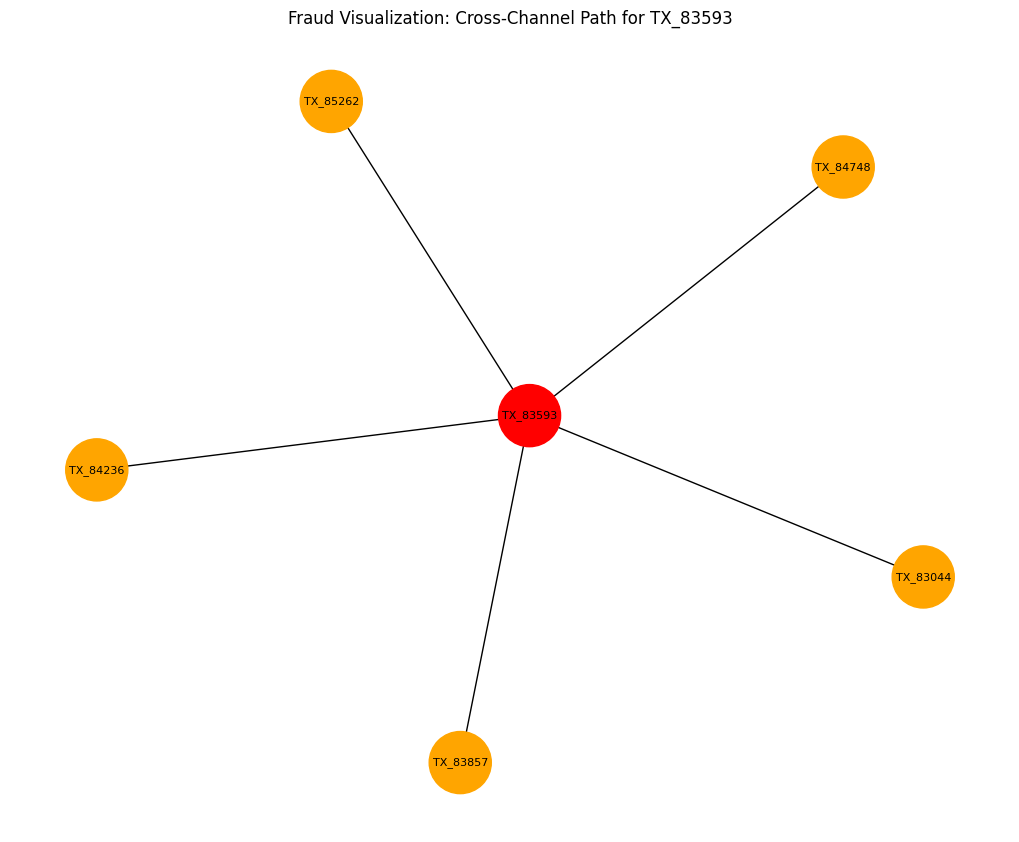

In [111]:
# Calculate Degree Centrality (how many connections each transaction has)
# High degree = high activity hub
edge_index_btc = data['transaction', 'transacts_with', 'transaction'].edge_index
degrees = torch.bincount(edge_index_btc[0])

#  Find transactions that are:
# - High degree (connected to more than 5 others)
# - Predicted as Illicit
# - Part of the "Discovery" set (unbridged)
mule_candidates = np.where((degrees.cpu().numpy() > 5) & (preds == 1) & (actuals == 1))[0]

print(f" Potential 'Mule' Accounts Identified: {len(mule_candidates)}")

if len(mule_candidates) > 0:
    mule_idx = mule_candidates[0]
    print(f"Top Candidate: TX_{mule_idx}")
    print(f"Total Connections: {degrees[mule_idx].item()}")
    
    # Visualize this specific Mule Hub
    visualize_fraud_neighborhood(mule_idx, data)

In [112]:
# --- Load the Keystroke Data ---
keystroke_path = 'data/keystroke_dynamics_dataset/DSL-StrongPasswordData.csv'
keystroke_df = pd.read_csv(keystroke_path)

# ---  Create 'Typing DNA' Profiles ---
# We use Mean and Standard Deviation to capture the "rhythm" and "consistency"
# Timing features start from column 3 (H.period)
biometric_features = keystroke_df.groupby('subject').agg(['mean', 'std']).iloc[:, 2:]
# Flatten column names (e.g., H.period_mean, H.period_std)
biometric_features.columns = [f"{c[0]}_{c[1]}" for c in biometric_features.columns]

# --- Map to LANL Users ---
# We map our 51 biometric subjects to the first 51 users in our Cyber layer
target_users = unique_users[:51]
subject_map = dict(zip(biometric_features.index, target_users))
user_to_biom_idx = {u: i for i, u in enumerate(target_users)}

# ---  Update User Node Features ---
# We expand the user feature dimension to match the 62 biometric features
num_biom_feats = biometric_features.shape[1]
biom_x = torch.zeros((len(unique_users), num_biom_feats))

for sub_id, u_id in subject_map.items():
    u_idx = user_map[u_id]
    # Fill the 'known' users with their biometric DNA
    biom_x[u_idx] = torch.tensor(biometric_features.loc[sub_id].values, dtype=torch.float)

# Replace the user features in our main data object
data['user'].x = biom_x

print(f" Baseline 4 Initialized: {num_biom_feats} Biometric features mapped to 51 users.")

 Baseline 4 Initialized: 64 Biometric features mapped to 51 users.


In [113]:
# Re-initialize with new feature dimensions
model_v4 = DeepFraudGNN(64, 2)
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print("Training Baseline 4 (Biometric-Enhanced Discovery)...")
for epoch in range(1, 101):
    model_v4.train()
    optimizer_v4.zero_grad()
    out = model_v4(data.x_dict, data.edge_index_dict)
    loss = criterion(out, data['transaction'].y)
    loss.backward()
    optimizer_v4.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

# Final Evaluation
model_v4.eval()
with torch.no_grad():
    out = model_v4(data.x_dict, data.edge_index_dict)
    preds_v4 = out.argmax(dim=-1).cpu().numpy()
    
print("\n--- Baseline 4: Biometric Report ---")
print(classification_report(actuals, preds_v4, target_names=['Licit', 'Illicit']))

Training Baseline 4 (Biometric-Enhanced Discovery)...
Epoch 020 | Loss: 0.2952
Epoch 040 | Loss: 0.2096
Epoch 060 | Loss: 0.1680
Epoch 080 | Loss: 0.1397
Epoch 100 | Loss: 0.1183

--- Baseline 4: Biometric Report ---
              precision    recall  f1-score   support

       Licit       1.00      0.97      0.99    199224
     Illicit       0.43      0.88      0.58      4545

    accuracy                           0.97    203769
   macro avg       0.71      0.92      0.78    203769
weighted avg       0.98      0.97      0.98    203769



In [114]:
# 1. Create a dictionary mapping Transaction ID to its Timestep
# In the Elliptic features file: column 0 is txId, column 1 is the timestep
tx_to_step_map = dict(zip(elliptic_features[0], elliptic_features[1]))

# 2. Create a tensor to hold the timesteps for all nodes in the graph
# We initialize with zeros and fill based on our unique_wallets list
tx_timesteps = torch.zeros(len(unique_wallets), dtype=torch.long)

for i, tx_id in enumerate(unique_wallets):
    # We use .get() to handle cases where a tx_id might not be in our 50k row sample
    tx_timesteps[i] = tx_to_step_map.get(tx_id, 0)

# 3. Attach the attribute to the HeteroData object
data['transaction'].time_step = tx_timesteps

print(f"Success: Attached timesteps to {len(unique_wallets)} transaction nodes.")

Success: Attached timesteps to 203769 transaction nodes.


In [115]:
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels, edge_types):
        super().__init__()
        
        # This dynamically creates a SAGEConv for every relationship in the graph
        self.conv1 = HeteroConv({
            etype: SAGEConv(-1, hidden_channels) for etype in edge_types
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            etype: SAGEConv(-1, hidden_channels) for etype in edge_types
        }, aggr='sum')
        
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # First Layer (Hop 1)
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        
        # Second Layer (Hop 2)
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        
        return self.lin(x_dict['transaction'])

In [116]:
# Define Temporal Masks
# We split the Bitcoin data: Train on 1-34, Test on 35-49
train_mask = data['transaction'].time_step <= 34
test_mask = data['transaction'].time_step > 34
print(f"Nodes in Training Set (Steps 1-34): {train_mask.sum().item()}")
print(f"Nodes in Test Set (Steps 35-49): {test_mask.sum().item()}")

Nodes in Training Set (Steps 1-34): 136265
Nodes in Test Set (Steps 35-49): 67504


In [117]:

def run_experiment(data_object, mode='standard'):
    """
    Executes the GNN training with temporal splitting.
    Mode 'random' performs the mentor's requested random-link sanity check.
    """
    # Clone to avoid overwriting the original graph
    exp_data = data_object.clone()
    
    if mode == 'random':
        print("--- SANITY CHECK: RUNNING RANDOM LINK CONTROL ---")
        edge_index = exp_data['transaction', 'accessed_via', 'computer'].edge_index
        # Shuffle computer indices to break the meaningful link between Fraud and Redteam
        num_bridge_edges = edge_index.shape[1]
        random_indices = torch.randint(0, exp_data['computer'].num_nodes, (num_bridge_edges,))
        exp_data['transaction', 'accessed_via', 'computer'].edge_index[1] = random_indices
    else:
        print("--- STARTING: TEMPORAL DISCOVERY ---")

    # Add reverse edges for bidirectional message passing
    exp_data = T.ToUndirected()(exp_data)
    
    # Initialize Model
    model = DeepFraudGNN(64, 2, exp_data.edge_types)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Weighted Loss: 1.0 for Licit, 10.0 for Illicit
    weights = torch.tensor([1.0, 10.0])
    criterion = torch.nn.CrossEntropyLoss(weight=weights)

    # Training Loop
    for epoch in range(1, 101):
        model.train()
        optimizer.zero_grad()
        out = model(exp_data.x_dict, exp_data.edge_index_dict)
        
        # KEY: Only calculate loss on the TRAIN mask (Timesteps 1-34)
        loss = criterion(out[train_mask], exp_data['transaction'].y[train_mask])
        
        loss.backward()
        optimizer.step()
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {loss:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        out = model(exp_data.x_dict, exp_data.edge_index_dict)
        preds = out.argmax(dim=-1).numpy()
        actuals = exp_data['transaction'].y.numpy()

    # Return results for the TEST mask only (Timesteps 35-49)
    return actuals[test_mask], preds[test_mask]

# --- EXECUTION ---

# Run the Standard Model
act_std, pred_std = run_experiment(data, mode='standard')
print("\nResults: Standard Model (Future Predictions)")
print(classification_report(act_std, pred_std, target_names=['Licit', 'Illicit']))

# Run the Random Control (Sanity Check)
act_rnd, pred_rnd = run_experiment(data, mode='random')
print("\nResults: Random Control (Sanity Check)")
print(classification_report(act_rnd, pred_rnd, target_names=['Licit', 'Illicit']))

--- STARTING: TEMPORAL DISCOVERY ---
Epoch 020 | Train Loss: 0.2614
Epoch 040 | Train Loss: 0.1775
Epoch 060 | Train Loss: 0.1432
Epoch 080 | Train Loss: 0.1203
Epoch 100 | Train Loss: 0.1015

Results: Standard Model (Future Predictions)
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99     66421
     Illicit       0.46      0.43      0.44      1083

    accuracy                           0.98     67504
   macro avg       0.72      0.71      0.72     67504
weighted avg       0.98      0.98      0.98     67504

--- SANITY CHECK: RUNNING RANDOM LINK CONTROL ---
Epoch 020 | Train Loss: 0.2436
Epoch 040 | Train Loss: 0.1697
Epoch 060 | Train Loss: 0.1340
Epoch 080 | Train Loss: 0.1090
Epoch 100 | Train Loss: 0.0901

Results: Random Control (Sanity Check)
              precision    recall  f1-score   support

       Licit       0.99      0.98      0.99     66421
     Illicit       0.37      0.59      0.46      1083

    accuracy              